# Исследование данных M5

Здесь я разбираюсь, что вообще лежит в данных Walmart и какие закономерности стоит заложить в модель. Сами данные в репозиторий не кладу (правила соревнования), поэтому ноутбук запускается после `src/build_long.py` и `src/status.py`.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=DeprecationWarning)

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
DATA = "../data/"

## Что за данные

Три таблицы: продажи (одна строка, товар в магазине, дни идут колонками), календарь с праздниками и днями выдачи продуктовых талонов SNAP, и недельные цены. Я собрал их в одну длинную таблицу: одна строка, товар × магазин × день.

In [2]:
long = pd.read_parquet(DATA + "long.parquet")
long = long[long["launched"]]            # days before the first price: the item was not on sale yet
print(f"{len(long):,} rows, {long.groupby(['item_id', 'store_id'], observed=True).ngroups:,} series")
print("stores:", sorted(long["store_id"].unique()))
print(long["cat_id"].value_counts().to_dict())
print("columns:", list(long.columns))

46,881,677 rows, 30,490 series


stores: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']


{'FOODS': 21798313, 'HOUSEHOLD': 16282479, 'HOBBIES': 8800885}
columns: ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'date', 'wm_yr_wk', 'weekday', 'month', 'year', 'event_name_1', 'event_type_1', 'snap', 'sell_price', 'launched']


## Продажи всей сети по дням

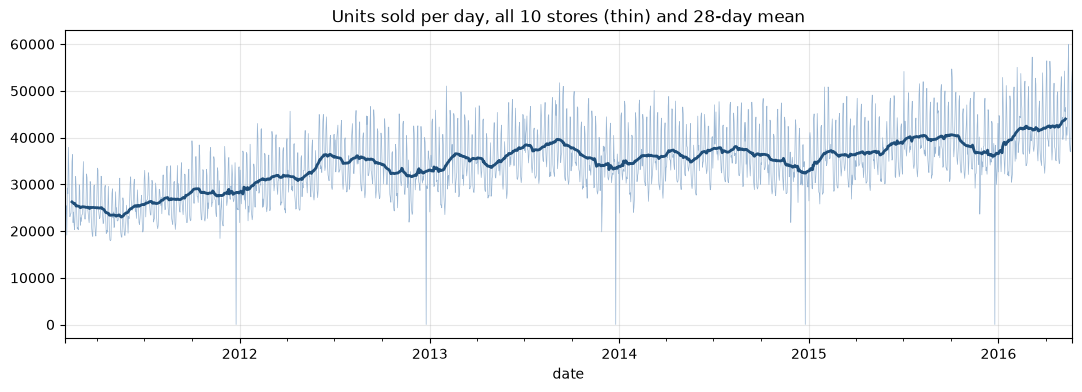

2011: 26281  2016: 41835
near-zero days: ['2011-12-25', '2012-12-25', '2013-12-25', '2014-12-25', '2015-12-25']


In [3]:
daily = long.groupby("date")["sales"].sum()
ax = daily.plot(figsize=(13, 4), lw=0.5, color="#9bb7d4")
daily.rolling(28, center=True).mean().plot(ax=ax, lw=2, color="#1f4e79")
ax.set_title("Units sold per day, all 10 stores (thin) and 28-day mean")
plt.show()
print("2011:", round(daily["2011"].mean()), " 2016:", round(daily["2016"].mean()))
print("near-zero days:", daily[daily < daily.median() * 0.2].index.strftime("%Y-%m-%d").tolist())

За пять лет продажи выросли примерно на 60%. Есть годовая волна (провал после новогодних, подъём летом) и частая «пила», недельный цикл. Пять точек около нуля приходятся на 25 декабря: магазины закрыты, и этот день я из обучения убрал.

## Категории и магазины

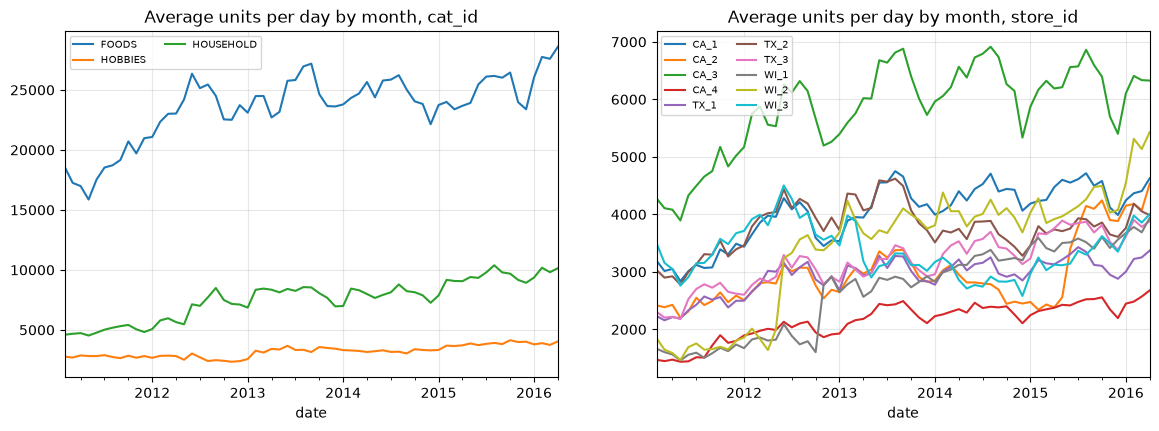

In [4]:
m = long[~((long["date"].dt.month == 12) & (long["date"].dt.day == 25))]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, key in zip(axes, ["cat_id", "store_id"]):
    t = m.groupby([pd.Grouper(key="date", freq="MS"), key], observed=True)["sales"].sum().unstack()
    (t.iloc[1:-1] / t.iloc[1:-1].index.days_in_month.values[:, None]).plot(ax=ax, lw=1.5)
    ax.set_title(f"Average units per day by month, {key}")
    ax.legend(fontsize=7, ncol=2)
plt.show()

На продукты приходится 69% всех проданных штук, и они же дают главную сезонность. Товары для дома растут ровнее всех, хобби почти не меняются.

У трёх магазинов видны скачки, которые не похожи на сезон: WI_1 и WI_2 в 2012 году, CA_2 в середине 2015-го. Проверил, что там происходило:

In [5]:
g = long.assign(month=long["date"].values.astype("datetime64[M]")).groupby(["store_id", "month"], observed=True)
g = g["sales"].agg(rows="size", units="sum")
g["items_on_sale"] = (g["rows"] / pd.to_datetime(g.index.get_level_values("month")).days_in_month).round()
g["units_per_item"] = (g["units"] / g["rows"]).round(2)
for store, months in [("WI_1", ("2012-09", "2012-12")), ("WI_2", ("2012-03", "2012-07")), ("CA_2", ("2015-04", "2015-08"))]:
    x = g.loc[store].loc[months[0]:months[1], ["items_on_sale", "units_per_item"]]
    x.index = x.index.strftime("%Y-%m")
    print(store); print(x.T.to_string()); print()

WI_1
month           2012-09  2012-10  2012-11  2012-12
items_on_sale    1796.0  1903.00  2153.00  2180.00
units_per_item      1.0     0.84     1.29     1.34

WI_2
month           2012-03  2012-04  2012-05  2012-06  2012-07
items_on_sale   1643.00  1698.00  1937.00  2002.00  2066.00
units_per_item     1.12     0.97     1.03     1.62     1.61

CA_2
month           2015-04  2015-05  2015-06  2015-07  2015-08
items_on_sale   2772.00  2821.00  2992.00  3003.00  3012.00
units_per_item     0.86     0.91     1.14     1.26     1.38



В момент скачка одновременно растёт и число товаров в продаже (+7–18%), и продажи на один товар (+50–67%). Похоже на расширение или реконструкцию магазина. Предсказать такое нельзя, но модель должна быстро подстроиться, поэтому в признаках главное место занимают свежие средние, а не история за пять лет.

## Качество данных: пропуски, нули, выбросы

In [6]:
print("missing:", long.isna().sum()[lambda s: s > 0].to_dict())
print(f"zero sales: {(long['sales'] == 0).mean():.1%}")
print("sales quantiles:", long["sales"].quantile([.5, .9, .99, .999]).to_dict(), "max:", long["sales"].max())
top = long.loc[long["sales"].idxmax()]
print(f"the biggest day: {top['sales']} units at ${top['sell_price']:.2f}, category {top['cat_id']}")
p = long["sell_price"]
print(f"prices: {p.min():.2f} .. {p.max():.2f}, below $0.10: {(p < 0.10).sum():,} rows")

missing: {'event_name_1': 43073327, 'event_type_1': 43073327}
zero sales: 59.6%


sales quantiles: {0.5: 0.0, 0.9: 4.0, 0.99: 17.0, 0.999: 51.0} max: 763
the biggest day: 763 units at $1.00, category FOODS


prices: 0.01 .. 107.32, below $0.10: 1,617 rows


Пропуски есть только в колонках праздников: в большинство дней праздника просто нет. Нулей 60%. Рекорд в 763 штуки за день похож на дешёвый ходовой продукт, это не ошибка. А вот цены по одному центу у товаров, которые обычно стоят $9, явно ошибка, такие цены заменяю медианой.

## Нули: «не купили» или «не было на полке»

Самое важное наблюдение. У половины рядов хотя бы раз была серия нулей длиннее трёх месяцев. Три месяца без единой продажи у товара, который до этого продавался, это почти наверняка пустая полка. Если учить модель на таких нулях, она научится занижать спрос.

Остатков в данных нет, поэтому статус я вычисляю: серия из L нулей у товара, который продаётся в доле p дней, случайно бывает с вероятностью (1 − p)^L. Если меньше 0,1%, товара не было. Сам расчёт в `src/status.py`, здесь итог:

In [7]:
st = pd.read_parquet(DATA + "status.parquet")
names = {0: "on sale", 1: "out of stock", 2: "delisted", 3: "not launched"}
print((st["status"].map(names).value_counts(normalize=True) * 100).round(2).to_dict())

{'on sale': 66.75, 'not launched': 20.79, 'out of stock': 12.39, 'delisted': 0.07}


Правило проверял на перемешанных во времени продажах: там настоящих провалов нет, и оно срабатывает на 1,4% дней против 15,7% на реальных. Глазами смотрел на десятке товаров; первая версия правила (по среднему числу проданных штук) слишком часто срабатывала у редких товаров, поэтому перешёл на долю дней с продажами.

## Корреляции

Беру 2000 случайных рядов и добавляю признаки, которые будут у модели: лаги и средние со сдвигом на 28 дней. Корреляция Спирмена, потому что продажи сильно скошены.

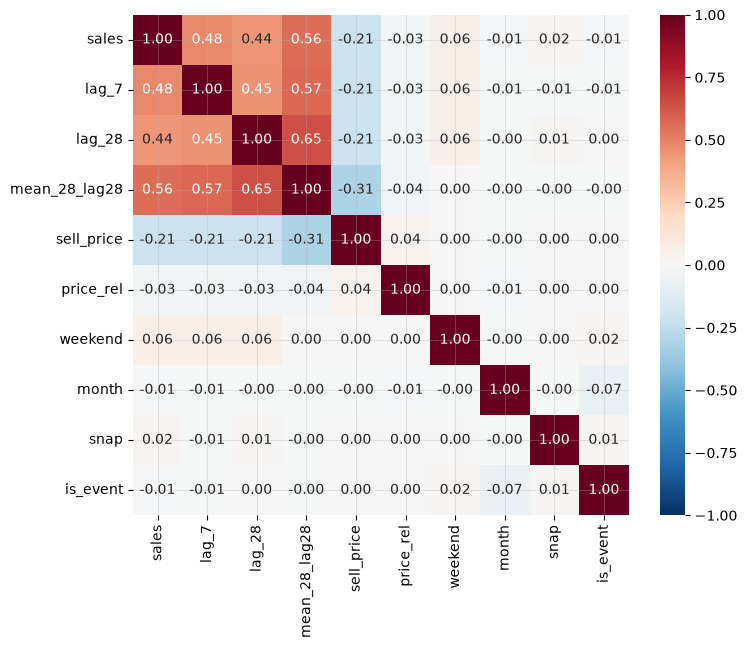

In [8]:
rng = np.random.default_rng(42)
key = long["item_id"].astype(str) + "_" + long["store_id"].astype(str)
pick = rng.choice(key.unique(), 2000, replace=False)
s = long[key.isin(pick)].assign(series=key[key.isin(pick)]).sort_values(["series", "date"])
g = s.groupby("series")["sales"]
s["lag_7"], s["lag_28"] = g.shift(7), g.shift(28)
s["mean_28_lag28"] = g.transform(lambda x: x.shift(28).rolling(28).mean())
s["price_rel"] = s["sell_price"] / s.groupby("series")["sell_price"].transform("mean")
s["weekend"] = s["date"].dt.dayofweek.ge(5).astype(int)
s["is_event"] = s["event_name_1"].notna().astype(int)
cols = ["sales", "lag_7", "lag_28", "mean_28_lag28", "sell_price", "price_rel", "weekend", "month", "snap", "is_event"]
c = s[cols].dropna().corr(method="spearman")
plt.figure(figsize=(8, 6.5))
sns.heatmap(c, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.show()

Сильнее всего с продажами связаны прошлые продажи, причём среднее за 28 дней (0,56) надёжнее отдельного дня (0,44). Цена −0,21, но это «дешёвые товары продаются чаще», а изменение цены одного товара почти ни на что не влияет (−0,03). Месяц, праздники и SNAP около нуля: корреляция не видит волн, поэтому их смотрю отдельно ниже.

## День недели × месяц

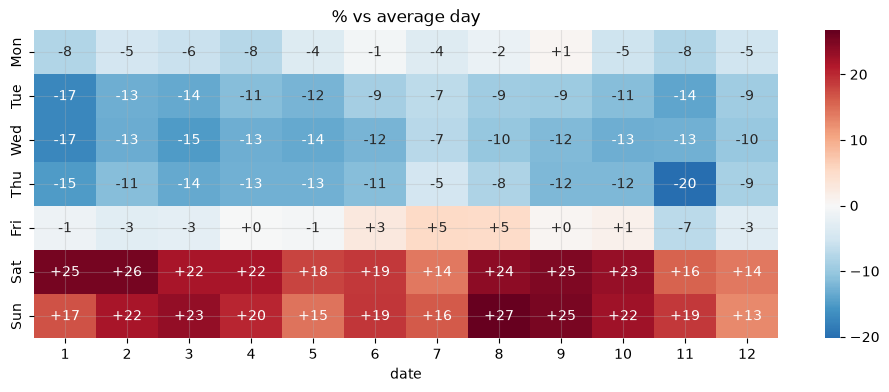

In [9]:
d = daily[~((daily.index.month == 12) & (daily.index.day == 25))]
t = d.groupby([d.index.dayofweek, d.index.month]).mean().unstack()
t.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
plt.figure(figsize=(12, 4))
sns.heatmap((t / d.mean() - 1) * 100, annot=True, fmt="+.0f", cmap="RdBu_r", center=0)
plt.title("% vs average day")
plt.show()

Суббота и воскресенье +20%, вторник–четверг −12%. Месяц двигает продажи всего на ±4%. Отдельно выделяется четверг ноября −20%, это День благодарения.

## Типы спроса

Классификация Syntetos–Boylan: как часто товар продаётся (ADI, средний интервал между продажами) и насколько разный размер покупки (CV²). Считаю только по дням, когда товар был в наличии.

In [10]:
on = long.merge(st, on=["item_id", "store_id", "d"])
on = on[on["status"] == 0]
gg = on.groupby(["item_id", "store_id"], observed=True)
nz = on[on["sales"] > 0].groupby(["item_id", "store_id"], observed=True)["sales"]
t = pd.DataFrame({"days": gg.size(), "n_sale": nz.size(), "m": nz.mean(), "sd": nz.std(ddof=0),
                  "units": gg["sales"].sum(), "cat": gg["cat_id"].first()}).dropna()
t["adi"], t["cv2"] = t["days"] / t["n_sale"], (t["sd"] / t["m"]) ** 2
a, cv = t["adi"] >= 1.32, t["cv2"] >= 0.49
t["type"] = np.select([~a & ~cv, ~a & cv, a & ~cv], ["smooth", "erratic", "intermittent"], "lumpy")
print((t["type"].value_counts(normalize=True) * 100).round(1).to_dict())
print("share of units:", (t.groupby("type")["units"].sum() / t["units"].sum() * 100).round(1).to_dict())
pd.crosstab(t["cat"], t["type"], normalize="index").round(2)

{'intermittent': 68.1, 'lumpy': 14.5, 'smooth': 10.8, 'erratic': 6.5}
share of units: {'erratic': 25.1, 'intermittent': 24.1, 'lumpy': 12.4, 'smooth': 38.3}


type,erratic,intermittent,lumpy,smooth
cat,,,,
FOODS,0.11,0.54,0.20,0.15
HOBBIES,0.03,0.79,0.17,0.02
HOUSEHOLD,0.02,0.82,0.06,0.10


Две трети товаров продаются с паузами (intermittent), но по объёму картина обратная: ровные и скачущие товары, меньше пятой части ассортимента, а дают 63% продаж. Для модели это значит две вещи: нужна функция потерь, которая умеет в данные с кучей нулей (Tweedie), и качество надо смотреть отдельно по типам спроса, иначе провал на редких товарах спрячется за ходовыми.

## Парето по выручке за последний год

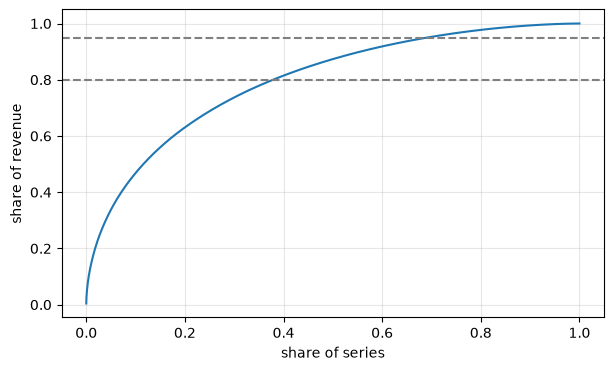

80% of revenue: 38% of series; last 31% give 5%


In [11]:
last = long[long["date"] > long["date"].max() - pd.Timedelta(days=365)]
rev = (last["sales"] * last["sell_price"]).groupby([last["item_id"], last["store_id"]], observed=True).sum().sort_values(ascending=False)
cum = rev.cumsum() / rev.sum()
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(cum) + 1) / len(cum), cum.values)
plt.axhline(0.8, ls="--", c="grey"); plt.axhline(0.95, ls="--", c="grey")
plt.xlabel("share of series"); plt.ylabel("share of revenue")
plt.show()
print(f"80% of revenue: {(cum <= 0.8).mean():.0%} of series; last {(cum > 0.95).mean():.0%} give 5%")

Не классическое 20/80: 38% товаров дают 80% выручки. Ассортимент у Walmart уже вычищен. ABC в признаки не беру, он дублирует цену и объём и подглядывает в будущее. Но использую его как вес ошибки: промах на дорогом ходовом товаре стоит дороже.

## Праздники по отдельности

Сравниваю продажи в праздник с тем же днём недели за 1–4 недели до и после, чтобы недельный цикл не мешал.

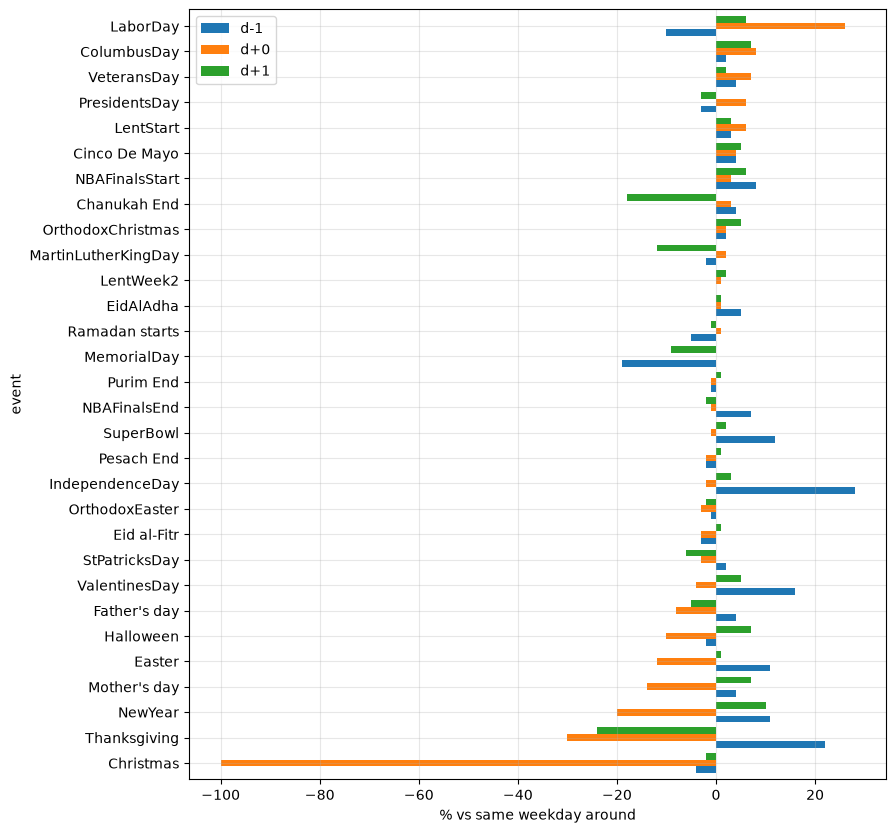

In [12]:
cal = pd.read_csv(DATA + "calendar.csv", parse_dates=["date"])
ev_days = set(cal.loc[cal["event_name_1"].notna(), "date"])
def effect(day):
    base = [daily.get(day + pd.Timedelta(weeks=w)) for w in (-4, -3, -2, -1, 1, 2, 3, 4)
            if day + pd.Timedelta(weeks=w) not in ev_days]
    base = [b for b in base if b is not None]
    return daily.get(day) / np.mean(base) - 1 if len(base) >= 4 and day in daily.index else np.nan
rows = [{"event": r.event_name_1, **{f"d{o:+d}": effect(r.date + pd.Timedelta(days=o)) for o in (-1, 0, 1)}}
        for r in cal[cal["event_name_1"].notna()].itertuples()]
ev = pd.DataFrame(rows).groupby("event").mean().sort_values("d+0")
(ev * 100).round(0).plot.barh(figsize=(9, 10), width=0.8)
plt.xlabel("% vs same weekday around"); plt.show()

Большинство праздников ничего не меняют. Сильные те, к которым закупаются: в День независимости −2%, а накануне +28%; накануне Дня благодарения +22%, Нового года +11%. После праздника тоже бывает эффект: на следующий день после Хэллоуина +7% (распродают конфеты). Поэтому в признаках не «есть праздник», а сколько дней до ближайшего сильного праздника и после него.

## SNAP, дни выдачи продуктовых талонов

In [13]:
agg = long[~((long["date"].dt.month == 12) & (long["date"].dt.day == 25))]
t = agg.groupby(["date", "state_id", "cat_id"], observed=True)["sales"].sum().unstack(["state_id", "cat_id"])
rel = t / t.rolling(28, center=True, min_periods=20).mean()
rel = rel / rel.groupby(rel.index.dayofweek).transform("mean")
cal_i = cal.set_index("date")
eff = {(s_, c_): rel.loc[cal_i.loc[rel.index, f"snap_{s_}"].values == 1, (s_, c_)].mean()
       / rel.loc[cal_i.loc[rel.index, f"snap_{s_}"].values == 0, (s_, c_)].mean() - 1 for s_, c_ in rel.columns}
(pd.Series(eff).unstack() * 100).round(1)

,FOODS,HOBBIES,HOUSEHOLD
CA,10.1,2.8,3.8
TX,14.8,1.7,2.6
WI,28.0,1.4,3.1


Продукты в дни SNAP: Калифорния +10%, Техас +15%, Висконсин +28%, а хобби и товары для дома почти не реагируют. Во второй половине месяца продукты проседают на 10–16%, деньги кончаются. Для малого бизнеса аналог SNAP это дни зарплаты, аванса и пенсий.

## Автокорреляция

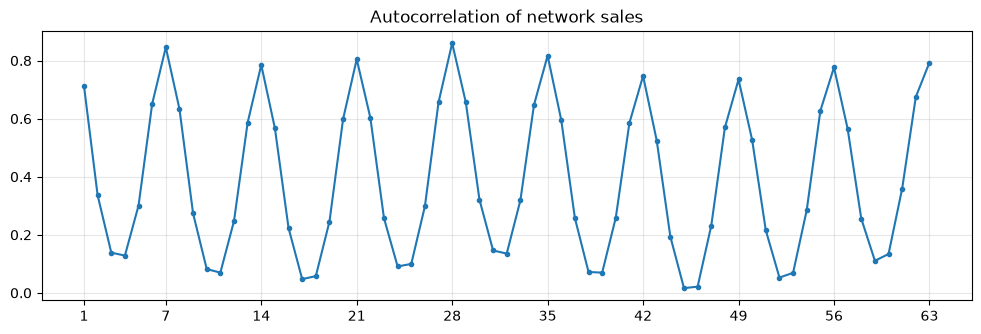

In [14]:
total = daily[~((daily.index.month == 12) & (daily.index.day == 25))]
lags = range(1, 64)
plt.figure(figsize=(12, 3.5))
plt.plot(lags, [total.autocorr(l) for l in lags], "o-", ms=3)
plt.xticks([1, 7, 14, 21, 28, 35, 42, 49, 56, 63]); plt.title("Autocorrelation of network sales")
plt.show()

Пики ровно на 7, 14, 21, 28 днях: неделя главный ритм. У отдельного редкого товара автокорреляция всего около 0,06: один день прошлого почти ничего не говорит, нужны средние. Прогнозирую на 28 дней вперёд прямой стратегией, поэтому беру лаги от 28 дней (28, 35, 42…), там недельные пики сохраняются.

## Новинки

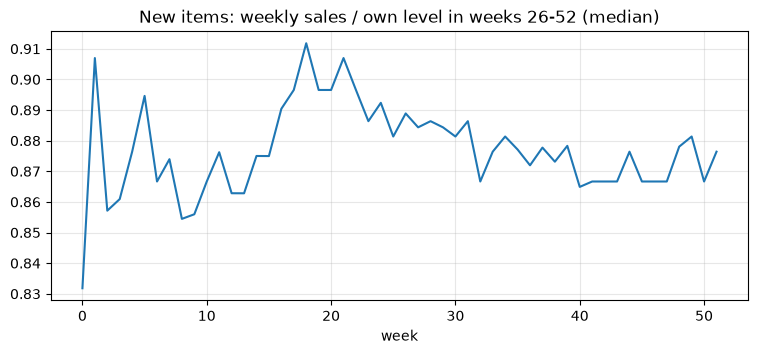

In [15]:
first = long.groupby(["item_id", "store_id"], observed=True)["date"].transform("min")
newer = long[first > long["date"].min() + pd.Timedelta(days=60)].copy()
newer["week"] = (newer["date"] - first[newer.index]).dt.days // 7
w = newer[newer["week"] < 52].groupby(["item_id", "store_id", "week"], observed=True)["sales"].mean()
mature = w[w.index.get_level_values("week") >= 26].groupby(level=[0, 1], observed=True).mean()
rel_w = (w / mature.reindex(w.index.droplevel("week")).values).groupby(level="week").median()
rel_w.plot(figsize=(9, 3.5), title="New items: weekly sales / own level in weeks 26-52 (median)")
plt.show()

Новинки раскачиваются быстро: продукты уже со второй недели продаются на 85% от «взрослого» уровня. Поэтому «новинка» у меня это первые 4 недели. Одна оговорка: в M5 цена появляется с недели первой продажи, так что дата «запуска» известна с точностью до недели.

## Цена

Сравниваю, как меняются продажи на неделе, когда изменилась цена, за вычетом общего фона той же недели.

In [16]:
wk = on.groupby(["item_id", "store_id", "wm_yr_wk"], observed=True).agg(price=("sell_price", "first"), y=("sales", "mean"),
                                                                         n=("sales", "size"), cat=("cat_id", "first"))
wk = wk[wk["n"] >= 5].reset_index().sort_values(["store_id", "item_id", "wm_yr_wk"])
gw = wk.groupby(["item_id", "store_id"], observed=True)
wk["dp"] = wk["price"] / gw["price"].shift() - 1
wk["dy"] = np.log((wk["y"] + 0.1) / (gw["y"].shift() + 0.1))
wk = wk.dropna(subset=["dp", "dy"])
bins = [-1, -0.3, -0.1, -0.03, 0.03, 0.1, 0.3, 5]
res = wk.groupby(pd.cut(wk["dp"], bins), observed=True)["dy"].median()
((np.exp(res - res.iloc[3]) - 1) * 100).round(1)

dp
(-1.0, -0.3]      0.0
(-0.3, -0.1]      0.0
(-0.1, -0.03]    13.0
(-0.03, 0.03]     0.0
(0.03, 0.1]       6.0
(0.1, 0.3]       10.8
(0.3, 5.0]        6.0
Name: dy, dtype: float64

Ждал «скидка → продажи растут», а сильные скидки идут вместе с падением продаж. Это распродажи уходящих товаров: цена следствие, а не причина. Честно оценить эластичность на этих данных нельзя, поэтому цену оставляю обычным признаком, а рекомендаций по цене в проекте нет.

## Какие признаки беру и почему

Главное, что показали данные: у отдельного товара в отдельный день очень много шума, а все календарные эффекты по сравнению с ним маленькие. Поэтому основа модели это собственный уровень продаж товара, а всё остальное поправки к нему.

**История продаж.** Средние за 7, 28 и 56 дней и лаги 28, 35, 42, 49, 56 дней. Корреляция у средних выше, чем у отдельных дней (0,56 против 0,44), и у редких товаров один день прошлого почти ничего не говорит. Сдвиг минимум 28 дней, потому что прогноз на 28 дней вперёд, и модель не должна видеть то, чего в момент прогноза ещё нет. Средние считаю только по дням, когда товар был в наличии, иначе пустая полка тянет уровень вниз. Отдельно среднее того же дня недели за четыре недели: оно ловит недельный ритм конкретного товара.

**Редкие товары.** Доля дней с продажами, средний размер покупки и разброс. Две трети товаров продаются с паузами, и уровень продаж их плохо описывает: одна штука каждый день и семь штук раз в неделю дают одно и то же среднее.

**Календарь.** День недели обязательно (выходные +20%), месяц и день месяца как слабые поправки. Для праздников не общий флаг, а для каждого сильного праздника отдельно, сколько дней до него и после: эффект сидит в канун и на следующий день, а большинство праздников вообще ничего не меняют. SNAP по штату магазина, потому что для продуктов это до +28%.

**Цена.** Сама цена и цена относительно обычной для товара. Сильным признаком она не будет, но дешёвые товары продаются чаще, и это стоит знать модели. Эластичность из неё не вытащить.

**Новизна.** Сколько дней товар на полке и флаг первых четырёх недель: раскачка короткая, дальше новинка ведёт себя как обычный товар.

**Что сознательно не взял.** Класс ABC и тип спроса ярлыком: оба считаются по всей истории, то есть подглядывают в будущее, и дублируют уровень продаж. Флаг «нет на полке» по полной длине серии нулей: он тоже знает будущее, поэтому в признаках только его честная версия на текущий день, а полный флаг убирает такие дни из обучения. Рекомендации по цене: данных для этого нет.

**Что не идёт в обучение как спрос.** Дни «нет на полке» и «снят с продажи», 25 декабря и дни до запуска товара.